## Lab19: Analyze Flights Delay Dataset
Objectives

By the end of this lab, students will be able to:

Load and examine flight delay data from CSV files using Python pandas

Clean and standardize dataset columns for proper analysis

Filter datasets for targeted analysis

Group data by different factors (month, day)

Calculate average delay times

Apply data manipulation techniques for real-world flight delay analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv('/kaggle/input/datasets/akhtar1122/flight-delay-dataset-1/flights.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (10000, 660)

Column Names:
['MONTH', 'DAY_OF_WEEK', 'DISTANCE', 'SCHEDULED_DEPARTURE', 'ARRIVAL_DELAY', 'AIRLINE_AS', 'AIRLINE_B6', 'AIRLINE_DL', 'AIRLINE_EV', 'AIRLINE_F9', 'AIRLINE_HA', 'AIRLINE_MQ', 'AIRLINE_NK', 'AIRLINE_OO', 'AIRLINE_UA', 'AIRLINE_US', 'AIRLINE_VX', 'AIRLINE_WN', 'ORIGIN_AIRPORT_ABI', 'ORIGIN_AIRPORT_ABQ', 'ORIGIN_AIRPORT_ABR', 'ORIGIN_AIRPORT_ABY', 'ORIGIN_AIRPORT_ACK', 'ORIGIN_AIRPORT_ACT', 'ORIGIN_AIRPORT_ACV', 'ORIGIN_AIRPORT_ACY', 'ORIGIN_AIRPORT_ADK', 'ORIGIN_AIRPORT_ADQ', 'ORIGIN_AIRPORT_AEX', 'ORIGIN_AIRPORT_AGS', 'ORIGIN_AIRPORT_AKN', 'ORIGIN_AIRPORT_ALB', 'ORIGIN_AIRPORT_ALO', 'ORIGIN_AIRPORT_AMA', 'ORIGIN_AIRPORT_ANC', 'ORIGIN_AIRPORT_APN', 'ORIGIN_AIRPORT_ASE', 'ORIGIN_AIRPORT_ATL', 'ORIGIN_AIRPORT_ATW', 'ORIGIN_AIRPORT_AUS', 'ORIGIN_AIRPORT_AVL', 'ORIGIN_AIRPORT_AVP', 'ORIGIN_AIRPORT_AZO', 'ORIGIN_AIRPORT_BDL', 'ORIGIN_AIRPORT_BET', 'ORIGIN_AIRPORT_BFL', 'ORIGIN_AIRPORT_BGM', 'ORIGIN_AIRPORT_BGR', 'ORIGIN_AIRPORT_BHM', 'ORIGIN_AIRPORT_

In [5]:
# Check data types and missing values
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 660 entries, MONTH to DESTINATION_AIRPORT_YUM
dtypes: bool(655), int64(5)
memory usage: 6.6 MB
None

Missing Values:
MONTH                      0
DAY_OF_WEEK                0
DISTANCE                   0
SCHEDULED_DEPARTURE        0
ARRIVAL_DELAY              0
                          ..
DESTINATION_AIRPORT_WRG    0
DESTINATION_AIRPORT_WYS    0
DESTINATION_AIRPORT_XNA    0
DESTINATION_AIRPORT_YAK    0
DESTINATION_AIRPORT_YUM    0
Length: 660, dtype: int64

Basic Statistics:
              MONTH   DAY_OF_WEEK      DISTANCE  SCHEDULED_DEPARTURE  \
count  10000.000000  10000.000000  10000.000000         10000.000000   
mean       6.218800      3.919800    840.049300          1385.674200   
std        3.396245      1.996589    616.918534           475.377012   
min        1.000000      1.000000     31.000000             3.000000   
25%        3.000000      2.000000    376.750000          1005

In [7]:
# View column names
print("Columns in dataset:")
print(df.columns)

# Dataset information
df.info()

# Statistical summary
df.describe()

Columns in dataset:
Index(['MONTH', 'DAY_OF_WEEK', 'DISTANCE', 'SCHEDULED_DEPARTURE',
       'ARRIVAL_DELAY', 'AIRLINE_AS', 'AIRLINE_B6', 'AIRLINE_DL', 'AIRLINE_EV',
       'AIRLINE_F9',
       ...
       'DESTINATION_AIRPORT_TYS', 'DESTINATION_AIRPORT_UST',
       'DESTINATION_AIRPORT_VEL', 'DESTINATION_AIRPORT_VLD',
       'DESTINATION_AIRPORT_VPS', 'DESTINATION_AIRPORT_WRG',
       'DESTINATION_AIRPORT_WYS', 'DESTINATION_AIRPORT_XNA',
       'DESTINATION_AIRPORT_YAK', 'DESTINATION_AIRPORT_YUM'],
      dtype='object', length=660)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 660 entries, MONTH to DESTINATION_AIRPORT_YUM
dtypes: bool(655), int64(5)
memory usage: 6.6 MB


,MONTH,DAY_OF_WEEK,DISTANCE,SCHEDULED_DEPARTURE,ARRIVAL_DELAY
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.218800,3.919800,840.049300,1385.674200,0.497200
std,3.396245,1.996589,616.918534,475.377012,0.500017
min,1.000000,1.000000,31.000000,3.000000,0.000000
25%,3.000000,2.000000,376.750000,1005.000000,0.000000
50%,6.000000,4.000000,669.000000,1415.000000,0.000000
75%,9.000000,6.000000,1076.000000,1758.000000,1.000000
max,12.000000,7.000000,4817.000000,2359.000000,1.000000


In [8]:
print("Checking missing values...")

missing_values = df.isnull().sum()

print(missing_values)

Checking missing values...
MONTH                      0
DAY_OF_WEEK                0
DISTANCE                   0
SCHEDULED_DEPARTURE        0
ARRIVAL_DELAY              0
                          ..
DESTINATION_AIRPORT_WRG    0
DESTINATION_AIRPORT_WYS    0
DESTINATION_AIRPORT_XNA    0
DESTINATION_AIRPORT_YAK    0
DESTINATION_AIRPORT_YUM    0
Length: 660, dtype: int64


In [9]:
print("Handling missing values...")

df['ARRIVAL_DELAY'] = df['ARRIVAL_DELAY'].fillna(df['ARRIVAL_DELAY'].median())

print("Missing values handled successfully.")

Handling missing values...
Missing values handled successfully.


In [10]:
print("Filtering dataset for flights with distance greater than 1000 miles...")

filtered_df = df[df['DISTANCE'] > 1000]

print("Filtered dataset shape:", filtered_df.shape)

filtered_df.head()

Filtering dataset for flights with distance greater than 1000 miles...
Filtered dataset shape: (2955, 660)


,MONTH,DAY_OF_WEEK,DISTANCE,SCHEDULED_DEPARTURE,ARRIVAL_DELAY,AIRLINE_AS,AIRLINE_B6,AIRLINE_DL,AIRLINE_EV,AIRLINE_F9,...,DESTINATION_AIRPORT_TYS,DESTINATION_AIRPORT_UST,DESTINATION_AIRPORT_VEL,DESTINATION_AIRPORT_VLD,DESTINATION_AIRPORT_VPS,DESTINATION_AIRPORT_WRG,DESTINATION_AIRPORT_WYS,DESTINATION_AIRPORT_XNA,DESTINATION_AIRPORT_YAK,DESTINATION_AIRPORT_YUM
0,2,4,1608,148,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,7,2,1491,2105,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,3,1,1931,1730,0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
9,11,7,2338,1548,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11,12,1,2218,1733,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
print("Grouping data by month...")

delay_by_month = df.groupby('MONTH')['ARRIVAL_DELAY'].mean()

print("Average delay by month:")
print(delay_by_month)

Grouping data by month...
Average delay by month:
MONTH
1     0.535388
2     0.547866
3     0.503319
4     0.437500
5     0.554585
6     0.539924
7     0.538386
8     0.468553
9     0.388679
11    0.416965
12    0.504654
Name: ARRIVAL_DELAY, dtype: float64


In [12]:
print("Grouping data by day of week...")

delay_by_day = df.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean()

print("Average delay by day:")
print(delay_by_day)

Grouping data by day of week...
Average delay by day:
DAY_OF_WEEK
1    0.534505
2    0.478506
3    0.487788
4    0.507792
5    0.499671
6    0.469573
7    0.492424
Name: ARRIVAL_DELAY, dtype: float64


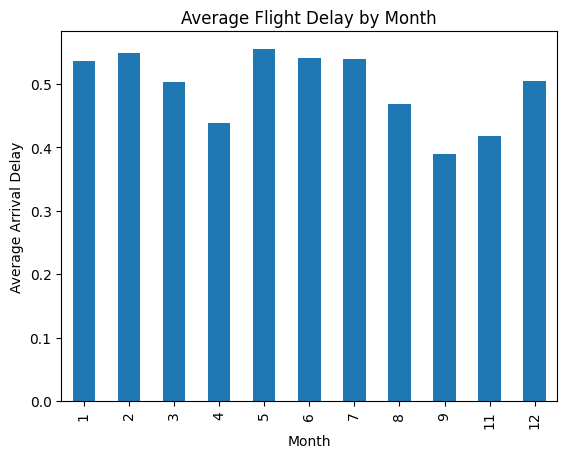

In [17]:
plt.figure()

delay_by_month.plot(kind='bar')

plt.title("Average Flight Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay")

plt.show()

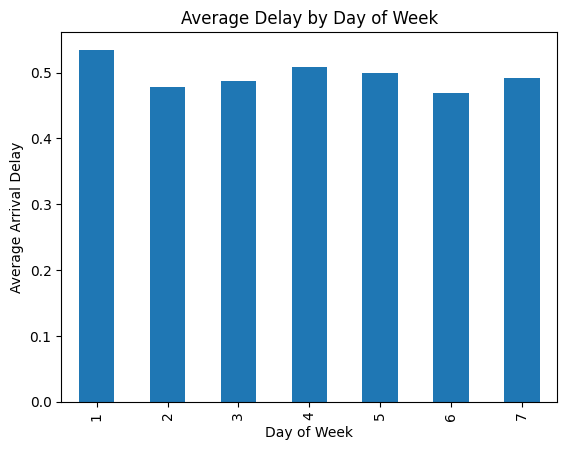

In [18]:
plt.figure()

delay_by_day.plot(kind='bar')

plt.title("Average Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Arrival Delay")

plt.show()

In [13]:
print("Calculating overall average delay...")

average_delay = df['ARRIVAL_DELAY'].mean()

print("Average Arrival Delay:", average_delay)

Calculating overall average delay...
Average Arrival Delay: 0.4972


In [14]:
print("Finding top delayed flights...")

top_delays = df.sort_values(by='ARRIVAL_DELAY', ascending=False)

print(top_delays[['MONTH','DAY_OF_WEEK','DISTANCE','ARRIVAL_DELAY']].head(10))

Finding top delayed flights...
      MONTH  DAY_OF_WEEK  DISTANCE  ARRIVAL_DELAY
9983      7            1       220              1
9980      2            7       109              1
9979      8            1       364              1
9978      8            1       447              1
9977      5            7       522              1
9975      9            5       599              1
9974     11            7       108              1
9973      6            3       771              1
9971      5            7       488              1
28        9            3       331              1


In [15]:
print("Creating delay categories...")

def delay_category(delay):

    if delay <= 0:
        return "On Time"
    
    elif delay <= 30:
        return "Minor Delay"
    
    elif delay <= 60:
        return "Moderate Delay"
    
    else:
        return "Severe Delay"

df['DELAY_CATEGORY'] = df['ARRIVAL_DELAY'].apply(delay_category)

df[['ARRIVAL_DELAY','DELAY_CATEGORY']].head()

Creating delay categories...


,ARRIVAL_DELAY,DELAY_CATEGORY
0,1,Minor Delay
1,1,Minor Delay
2,1,Minor Delay
3,0,On Time
4,0,On Time


In [16]:
print("Analyzing delay category distribution...")

delay_distribution = df['DELAY_CATEGORY'].value_counts()

print(delay_distribution)

Analyzing delay category distribution...
DELAY_CATEGORY
On Time        5028
Minor Delay    4972
Name: count, dtype: int64


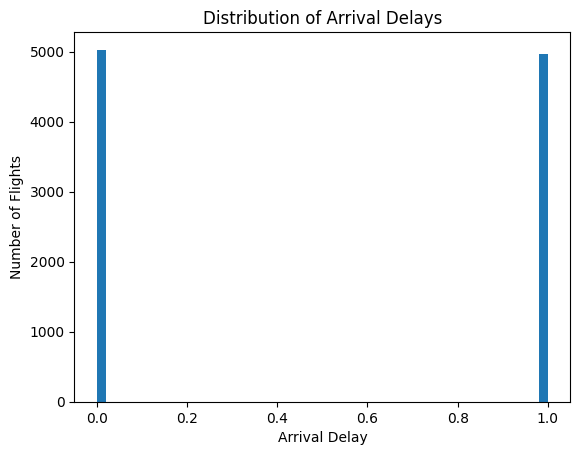

In [19]:
plt.figure()

plt.hist(df['ARRIVAL_DELAY'], bins=50)

plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay")
plt.ylabel("Number of Flights")

plt.show()

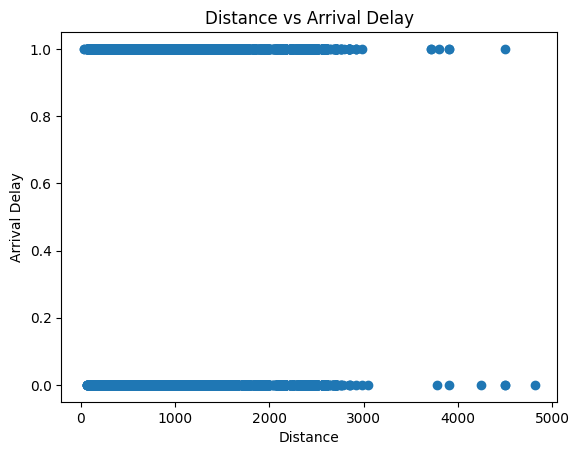

In [20]:
plt.figure()

plt.scatter(df['DISTANCE'], df['ARRIVAL_DELAY'])

plt.title("Distance vs Arrival Delay")
plt.xlabel("Distance")
plt.ylabel("Arrival Delay")

plt.show()

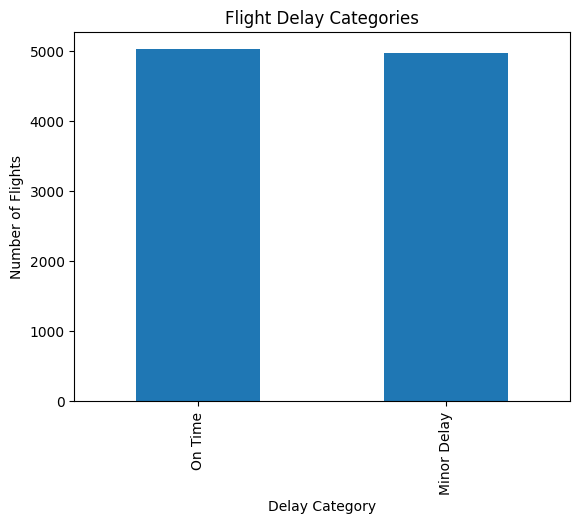

In [21]:
plt.figure()

delay_distribution.plot(kind='bar')

plt.title("Flight Delay Categories")
plt.xlabel("Delay Category")
plt.ylabel("Number of Flights")

plt.show()